# MCDI504 — Machine Learning I
# Avance del Proyecto — Fase 1: Definición y Orientación de la Situación
### Notebook F1_Definicion.ipynb

**Curso:** MCDI504 - Machine Learning I
**Grupo:** 5

**Integrantes:**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Fecha de entrega:** 9 de agosto de 2026

---

**Índice**
1. [Contexto y definición del problema](#1)
2. [Librerías necesarias](#2)
3. [Carga de la base de datos](#3)
4. [Análisis descriptivo inicial](#4)
5. [Visualización de la distribución con boxplot](#5)
6. [Transformación de variables categóricas](#6)
7. [Matriz de correlación de Pearson](#7)
8. [Matriz de p-valores](#8)
9. [Normalización de datos](#9)
10. [Base de datos normalizada completa](#10)
11. [Relación con la metodología KDD](#11)
12. [Clasificación del tipo de aprendizaje](#12)
13. [Comparación de enfoques](#13)
14. [Conclusiones](#14)

<a id="1"></a>
## 1. Contexto y definición del problema

### 1.1 Contexto del caso

**NextWork Advisory** es una consultora ficticia especializada en estrategia de talento y planificación de fuerza laboral. Sus clientes son empresas medianas y grandes que buscan anticipar el impacto de la automatización impulsada por Inteligencia Artificial sobre sus dotaciones de personal hacia el año 2030, con el fin de priorizar inversiones en recapacitación (*reskilling*) y rediseño de cargos.

Para sustentar sus recomendaciones, NextWork Advisory utiliza el dataset **AI Impact on Jobs 2030**, una base de datos simulada que modela cómo distintas profesiones, niveles educativos y perfiles de habilidades podrían verse afectados por la automatización impulsada por IA hacia 2030. El dataset contiene 3.000 registros de perfiles laborales, cada uno descrito por su cargo, salario promedio, años de experiencia, nivel educativo, un índice de exposición a la IA, un factor de crecimiento tecnológico del sector, un puntaje de dominio en 10 habilidades (Skill_1 a Skill_10), y dos variables de resultado: `Automation_Probability_2030` (probabilidad continua de automatización) y `Risk_Category` (categoría de riesgo: Low, Medium o High).

### 1.2 Situación que origina el análisis

Actualmente, NextWork Advisory clasifica el riesgo de automatización de los cargos de sus clientes de forma manual, basándose en la experiencia de sus consultores. Este método es lento, poco escalable y difícil de justificar objetivamente frente a los clientes. La consultora necesita evaluar si es posible construir, en fases posteriores del proyecto, un modelo capaz de estimar el nivel de riesgo de automatización de un cargo a partir de sus características observables (salario, experiencia, educación, exposición a la IA y perfil de habilidades).

### 1.3 Objetivo analítico del proyecto

Determinar, a partir de las características disponibles de cada perfil laboral, cuál es el enfoque de aprendizaje más adecuado para estimar el **nivel de riesgo de automatización (`Risk_Category`)** de un cargo hacia el año 2030, sentando la base metodológica para el modelamiento en fases posteriores del proyecto.

### 1.4 Relación entre problema, tipo de datos y objetivo

El dataset dispone de una variable de resultado ya etiquetada (`Risk_Category`) junto con variables predictoras estructuradas y numéricas/categóricas. Esta combinación —etiquetas conocidas más variables de entrada bien definidas— orienta el problema hacia un enfoque de **aprendizaje supervisado**, ya que el objetivo es aprender la relación entre las características de un cargo y su categoría de riesgo, para luego predecir dicha categoría en nuevos casos.

### 1.5 Formulación del problema

En un contexto de consultoría de talento, la evaluación del riesgo de automatización de un cargo suele depender del juicio experto de consultores, lo que introduce subjetividad y limita la escalabilidad del análisis a grandes carteras de clientes. La problemática analítica consiste en determinar si las variables disponibles sobre cada cargo (salario, experiencia, educación, exposición a la IA y habilidades) permiten fundamentar un enfoque de Machine Learning capaz de estimar de forma sistemática la categoría de riesgo de automatización.

### 1.6 Pregunta analítica

¿Cómo pueden las variables sociolaborales y de habilidades disponibles (`Average_Salary`, `Years_Experience`, `Education_Level`, `AI_Exposure_Index`, `Tech_Growth_Factor` y `Skill_1`–`Skill_10`) orientar la selección de un enfoque de aprendizaje supervisado para estimar la categoría de riesgo de automatización (`Risk_Category`) de un cargo hacia 2030?

### 1.7 Objetivo general

Definir y justificar el enfoque inicial de un proyecto de Machine Learning para la estimación del riesgo de automatización de cargos hacia 2030, mediante el análisis estructural, descriptivo y correlacional del dataset AI Impact on Jobs 2030, en el marco del proceso KDD.

### 1.8 Objetivos específicos

- Caracterizar la estructura del dataset, identificando observaciones, variables de entrada y variable de decisión.
- Analizar estadísticamente las variables numéricas mediante medidas descriptivas y visualizaciones iniciales.
- Evaluar relaciones lineales entre variables mediante la matriz de correlación de Pearson y sus p-valores asociados.
- Aplicar una transformación controlada de las variables categóricas ordinales (`Risk_Category`, `Education_Level`) para su análisis numérico, resguardando su interpretación categórica.
- Normalizar las variables de entrada para preparar la base de datos para futuros algoritmos sensibles a la escala.
- Relacionar las acciones realizadas en el notebook con las etapas de la metodología KDD.
- Comparar el enfoque de clasificación supervisada con alternativas metodológicas y justificar su selección.

### 1.9 Tipo de datos considerados

- **Variables numéricas continuas:** `Average_Salary`, `Years_Experience`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Automation_Probability_2030`, `Skill_1`–`Skill_10`.
- **Variables categóricas nominales:** `Job_Title` (20 categorías).
- **Variables categóricas ordinales:** `Education_Level` (High School < Bachelor's < Master's < PhD), `Risk_Category` (Low < Medium < High), variable de decisión del proyecto.

### 1.10 Alcance del análisis

Esta Fase 1 se limita a la definición del problema, la exploración descriptiva inicial de los datos y la justificación del enfoque de aprendizaje. **No se entrena ningún modelo predictivo en esta etapa**; el modelamiento y la evaluación de algoritmos de clasificación se abordarán en fases posteriores del proyecto (F2–F4).

### 1.11 Relación entre el problema definido y el proceso KDD

La metodología KDD (*Knowledge Discovery in Databases*) organiza la transformación de datos crudos en conocimiento útil a través de etapas sucesivas de selección, preprocesamiento, transformación, minería de datos e interpretación/evaluación (Fayyad et al., 1996). El presente notebook se sitúa principalmente en las etapas iniciales de **selección, preprocesamiento y transformación**, generando además evidencia descriptiva (correlaciones, p-valores) que orientará la etapa de **minería de datos** en las fases siguientes del proyecto.

<a id="2"></a>
## 2. Librerías necesarias

Importamos las librerías que usaremos para el análisis descriptivo, la visualización y el preprocesamiento de los datos.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr

<a id="3"></a>
## 3. Carga de la base de datos

Cargamos el dataset **AI Impact on Jobs 2030** desde el archivo CSV disponible en el repositorio del proyecto.

In [2]:
bbdd1 = pd.read_csv("../data/AI_Impact_on_Jobs_2030.csv")
bbdd1.head()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


<a id="4"></a>
## 4. Análisis descriptivo inicial

Realizamos un análisis descriptivo de las variables de entrada y de la variable de decisión `Risk_Category`.

In [3]:
print("Resumen estadístico:")
print(bbdd1.describe(include="all"))

print("\nEstructura de la base de datos:")
print(bbdd1.info())

Resumen estadístico:
                Job_Title  Average_Salary  Years_Experience Education_Level  \
count                3000     3000.000000       3000.000000            3000   
unique                 20             NaN               NaN               4   
top     Software Engineer             NaN               NaN     High School   
freq                  175             NaN               NaN             784   
mean                  NaN    89372.279000         14.677667             NaN   
std                   NaN    34608.088767          8.739788             NaN   
min                   NaN    30030.000000          0.000000             NaN   
25%                   NaN    58640.000000          7.000000             NaN   
50%                   NaN    89318.000000         15.000000             NaN   
75%                   NaN   119086.500000         22.000000             NaN   
max                   NaN   149798.000000         29.000000             NaN   

        AI_Exposure_Index  Tec

Revisamos también la frecuencia de las variables categóricas relevantes: los 20 cargos considerados, los niveles educativos y las categorías de riesgo de automatización.

In [4]:
print("Cargos considerados en el dataset:")
print(bbdd1["Job_Title"].value_counts())

print("\nNiveles educativos:")
print(bbdd1["Education_Level"].value_counts())

print("\nCategorías de riesgo de automatización (variable de decisión):")
print(bbdd1["Risk_Category"].value_counts())

print("\nValores nulos por columna:")
print(bbdd1.isnull().sum())

Cargos considerados en el dataset:
Job_Title
Software Engineer      175
UX Researcher          167
Data Scientist         167
Teacher                166
Graphic Designer       160
HR Specialist          157
Construction Worker    156
Retail Worker          155
Security Guard         154
Truck Driver           153
Financial Analyst      151
Research Scientist     149
Nurse                  142
Chef                   141
AI Engineer            140
Mechanic               136
Marketing Manager      134
Customer Support       133
Lawyer                 132
Doctor                 132
Name: count, dtype: int64

Niveles educativos:
Education_Level
High School    784
Bachelor's     765
Master's       735
PhD            716
Name: count, dtype: int64

Categorías de riesgo de automatización (variable de decisión):
Risk_Category
Medium    1521
High       740
Low        739
Name: count, dtype: int64

Valores nulos por columna:
Job_Title                      0
Average_Salary                 0
Years_E

<a id="5"></a>
## 5. Visualización de la distribución con boxplot

Un boxplot nos ayuda a visualizar la distribución de las variables numéricas y a identificar posibles *outliers*. Las variables del dataset presentan al menos tres escalas distintas —`Average_Salary` (miles de dólares), `Years_Experience` (0 a 29 años), `Tech_Growth_Factor` (factor entre 0.5 y 1.5) y los índices/habilidades acotados entre 0 y 1—, por lo que se visualizan en grupos separados.

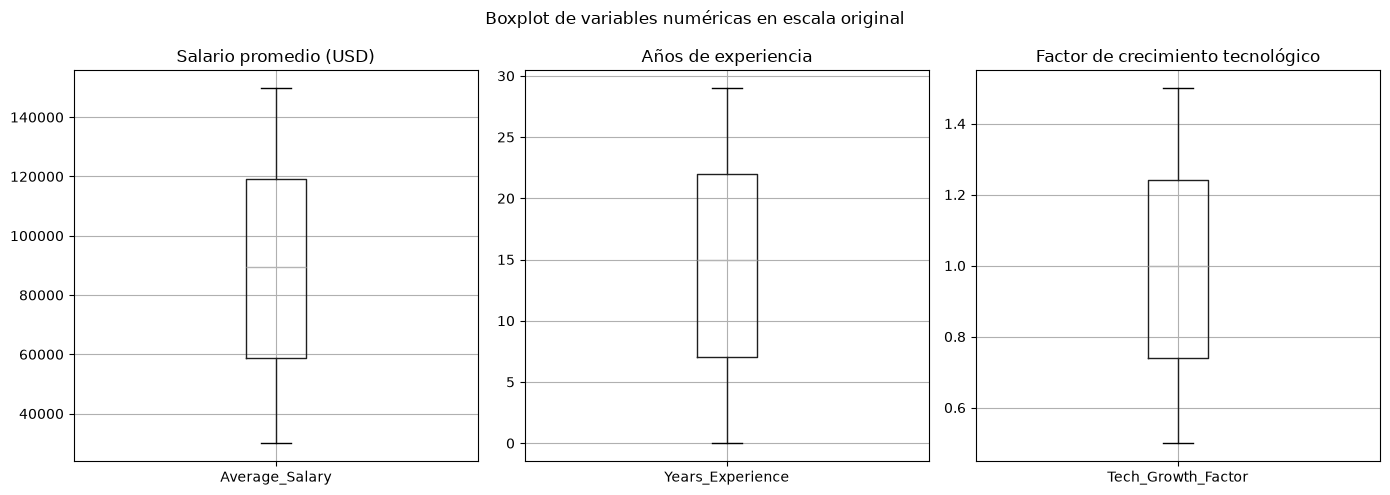

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

bbdd1[["Average_Salary"]].boxplot(ax=axes[0])
axes[0].set_title("Salario promedio (USD)")

bbdd1[["Years_Experience"]].boxplot(ax=axes[1])
axes[1].set_title("Años de experiencia")

bbdd1[["Tech_Growth_Factor"]].boxplot(ax=axes[2])
axes[2].set_title("Factor de crecimiento tecnológico")

plt.suptitle("Boxplot de variables numéricas en escala original")
plt.tight_layout()
plt.savefig("../figures/boxplot_salario_experiencia.png", dpi=150, bbox_inches="tight")
plt.show()

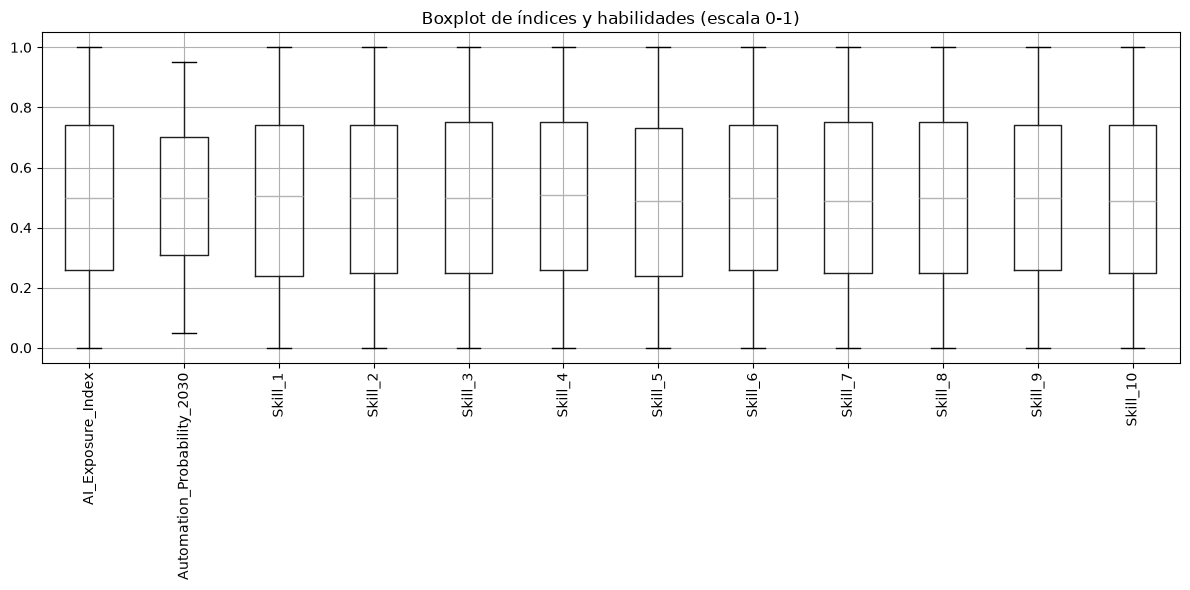

In [6]:
indices_habilidades = (
    ["AI_Exposure_Index", "Automation_Probability_2030"]
    + [f"Skill_{i}" for i in range(1, 11)]
)

plt.figure(figsize=(12, 6))
bbdd1[indices_habilidades].boxplot()
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("")
plt.title("Boxplot de índices y habilidades (escala 0-1)")
plt.tight_layout()
plt.savefig("../figures/boxplot_indices_habilidades.png", dpi=150, bbox_inches="tight")
plt.show()

Las escalas notoriamente distintas entre `Average_Salary` (miles de dólares), `Years_Experience` (0 a 29 años), `Tech_Growth_Factor` (0.5 a 1.5) y los índices/habilidades (0 a 1) evidencian la necesidad de **normalizar** las variables antes de utilizarlas en algoritmos sensibles a la escala, lo cual se aborda en la sección 9.

<a id="6"></a>
## 6. Transformación de variables categóricas ordinales

Tanto `Risk_Category` como `Education_Level` son variables categóricas **ordinales**. Para poder incluirlas en el análisis de correlación de Pearson, se codifican numéricamente respetando su orden natural (`Low` < `Medium` < `High` y `High School` < `Bachelor's` < `Master's` < `PhD`), de forma análoga a como el notebook guía recodificó la variable `Species` del dataset Iris.

In [7]:
bbdd2 = bbdd1.copy()

orden_riesgo = {"Low": 1, "Medium": 2, "High": 3}
bbdd2["Risk_Category_Num"] = bbdd2["Risk_Category"].map(orden_riesgo)

orden_educacion = {"High School": 1, "Bachelor's": 2, "Master's": 3, "PhD": 4}
bbdd2["Education_Level_Num"] = bbdd2["Education_Level"].map(orden_educacion)

bbdd2[["Risk_Category", "Risk_Category_Num", "Education_Level", "Education_Level_Num"]].head()

,Risk_Category,Risk_Category_Num,Education_Level,Education_Level_Num
0,High,3,Master's,3
1,Low,1,PhD,4
2,High,3,High School,1
3,Medium,2,PhD,4
4,Medium,2,High School,1


### Revisión y resumen de `bbdd2`

Verificamos la estructura y el resumen estadístico de la nueva base de datos con las variables categóricas codificadas numéricamente.

In [8]:
print("\nEstructura de bbdd2:")
print(bbdd2.info())

print("\nResumen estadístico de bbdd2:")
print(bbdd2.describe())


Estructura de bbdd2:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   str    
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   str    
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   str    
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6

<a id="7"></a>
## 7. Matriz de correlación de Pearson

Calculamos y visualizamos la matriz de correlación de Pearson para entender la relación lineal entre las variables numéricas y las variables ordinales codificadas.

In [9]:
variables_correlacion = (
    ["Average_Salary", "Years_Experience", "Education_Level_Num",
     "AI_Exposure_Index", "Tech_Growth_Factor"]
    + [f"Skill_{i}" for i in range(1, 11)]
    + ["Automation_Probability_2030", "Risk_Category_Num"]
)

correlacion = bbdd2[variables_correlacion].corr(method="pearson")

print("\nMatriz de correlación:")
print(correlacion)


Matriz de correlación:
                             Average_Salary  Years_Experience  \
Average_Salary                     1.000000          0.017389   
Years_Experience                   0.017389          1.000000   
Education_Level_Num                0.014944          0.039526   
AI_Exposure_Index                 -0.020196          0.034599   
Tech_Growth_Factor                -0.002214         -0.023371   
Skill_1                           -0.016888          0.011118   
Skill_2                           -0.021382          0.009353   
Skill_3                            0.019271         -0.016043   
Skill_4                           -0.024862         -0.025986   
Skill_5                           -0.010809         -0.001974   
Skill_6                           -0.015895         -0.002484   
Skill_7                            0.017232          0.006845   
Skill_8                           -0.005487          0.030740   
Skill_9                           -0.007120         -0.028956   
S

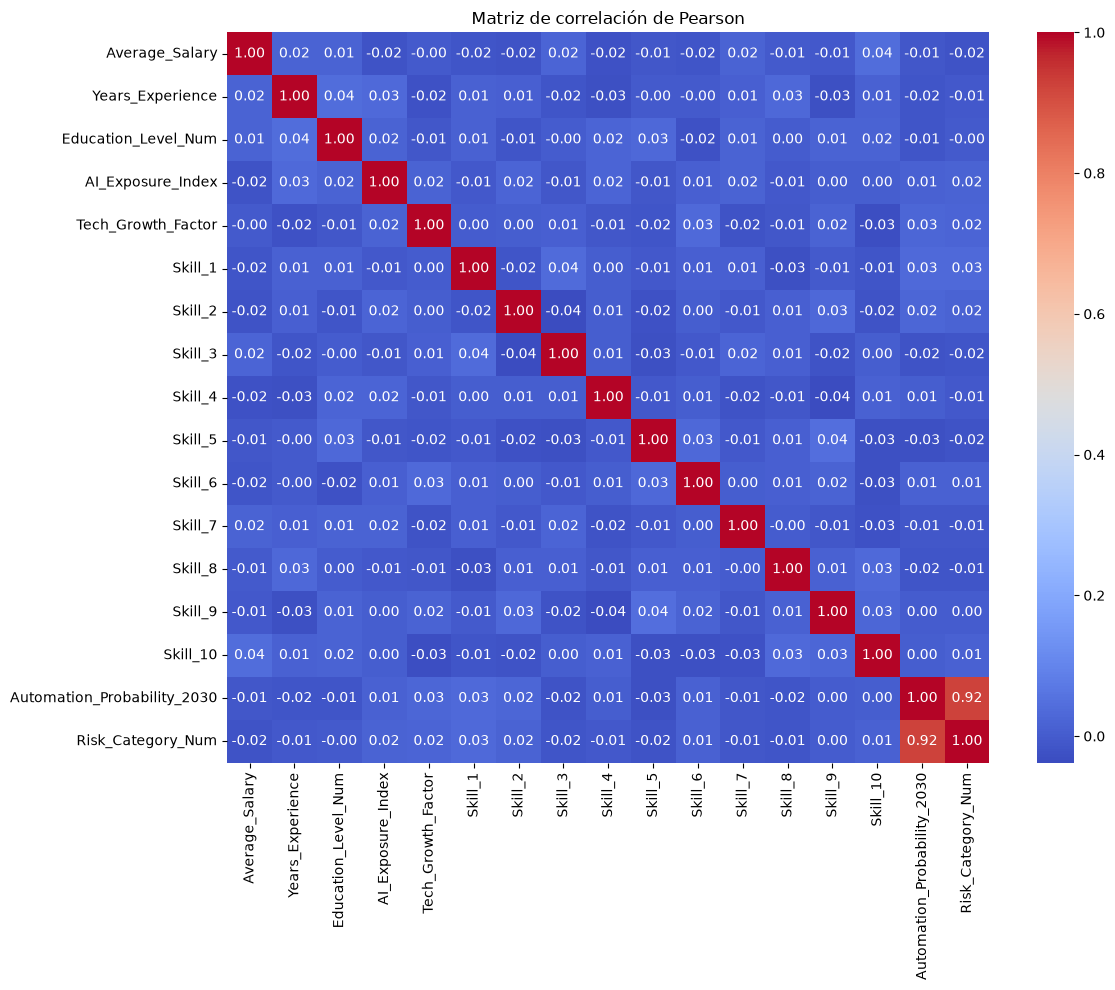

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.savefig("../figures/correlacion_pearson.png", dpi=150, bbox_inches="tight")
plt.show()

Como era esperable, `Risk_Category_Num` presenta una correlación muy alta con `Automation_Probability_2030` (~0.92), ya que la primera es una discretización directa de la segunda (`Low`: 0.05–0.30, `Medium`: 0.31–0.70, `High`: 0.71–0.95). En cambio, `Average_Salary`, `Years_Experience`, `Education_Level_Num`, `AI_Exposure_Index`, `Tech_Growth_Factor` y las variables `Skill_1`–`Skill_10` presentan correlaciones cercanas a cero con la probabilidad de automatización y con la categoría de riesgo. Esto sugiere que, en este dataset simulado, la relación entre las variables de perfil laboral y el riesgo de automatización **no es lineal** (o es simplemente ruido en la simulación), un antecedente relevante a considerar al seleccionar algoritmos en fases posteriores del proyecto.

<a id="8"></a>
## 8. Matriz de p-valores para la correlación de Pearson

Calculamos los p-valores asociados a cada coeficiente de correlación de Pearson. Un p-valor bajo (típicamente < 0.05) sugiere que la correlación es estadísticamente significativa, aunque su magnitud pueda ser pequeña.

In [11]:
def calculate_pvalues(df):
    df = df.dropna()._get_numeric_data()
    df_cols = df.columns
    pvalues = pd.DataFrame(np.ones(shape=(len(df_cols), len(df_cols))), columns=df_cols, index=df_cols)
    for col1 in df_cols:
        for col2 in df_cols:
            if col1 == col2:
                pvalues.loc[col1, col2] = 0.0
            else:
                _, p = pearsonr(df[col1], df[col2])
                pvalues.loc[col1, col2] = p
    return pvalues

pvalue_matrix = calculate_pvalues(bbdd2[variables_correlacion])

print("\nMatriz de p-valores (Correlación de Pearson):")
print(pvalue_matrix)


Matriz de p-valores (Correlación de Pearson):
                             Average_Salary  Years_Experience  \
Average_Salary                     0.000000          0.341035   
Years_Experience                   0.341035          0.000000   
Education_Level_Num                0.413231          0.030395   
AI_Exposure_Index                  0.268796          0.058115   
Tech_Growth_Factor                 0.903537          0.200652   
Skill_1                            0.355138          0.542709   
Skill_2                            0.241694          0.608588   
Skill_3                            0.291350          0.379718   
Skill_4                            0.173386          0.154741   
Skill_5                            0.553974          0.913931   
Skill_6                            0.384126          0.891805   
Skill_7                            0.345406          0.707840   
Skill_8                            0.763881          0.092302   
Skill_9                            0.696668

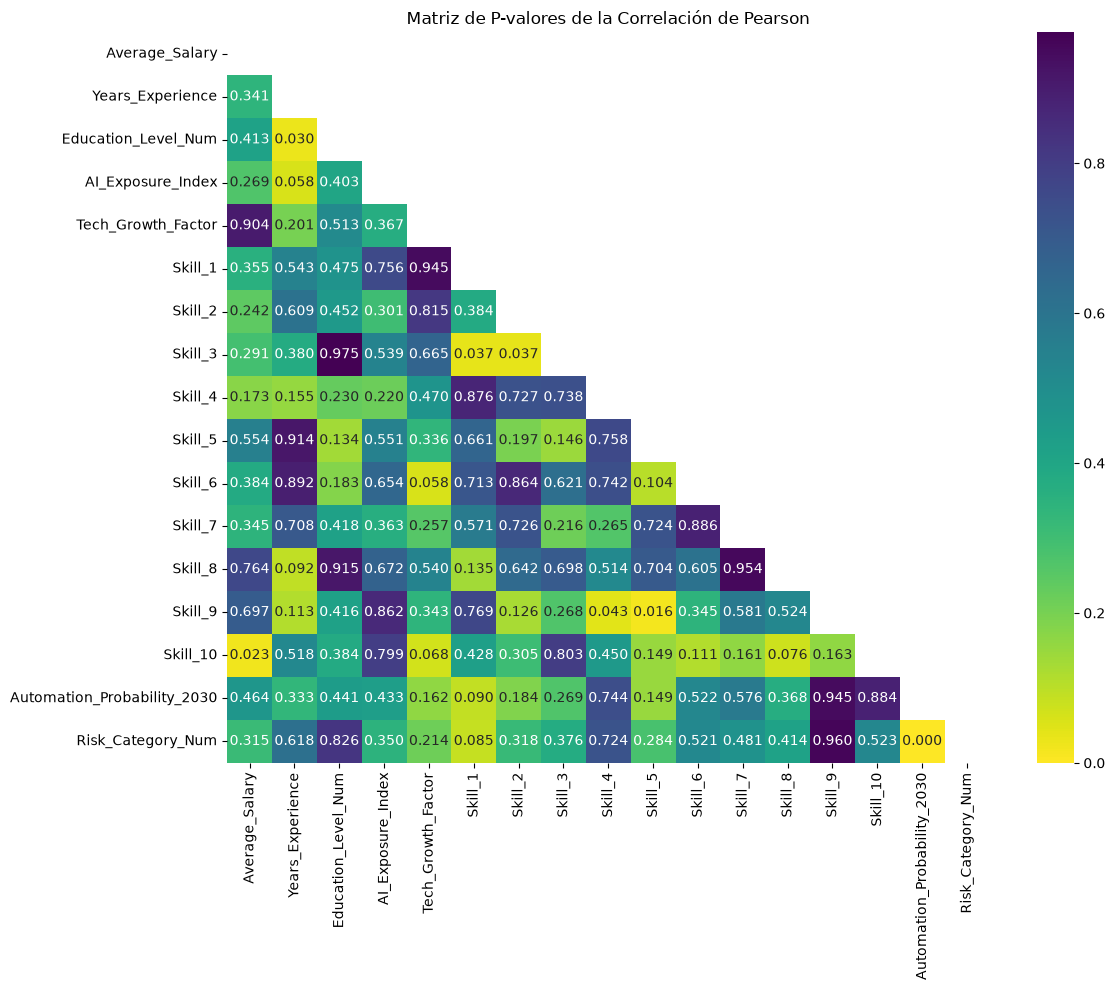

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    pvalue_matrix,
    annot=True,
    cmap="viridis_r",
    fmt=".3f",
    mask=np.triu(np.ones_like(pvalue_matrix, dtype=bool))
)
plt.title("Matriz de P-valores de la Correlación de Pearson")
plt.tight_layout()
plt.savefig("../figures/pvalores_pearson.png", dpi=150, bbox_inches="tight")
plt.show()

Varias correlaciones cercanas a cero resultan, aun así, estadísticamente significativas (p < 0.05) debido al gran tamaño muestral (3.000 observaciones), lo que confirma que la significancia estadística no implica necesariamente relevancia práctica. Esto refuerza la necesidad de evaluar en fases posteriores enfoques capaces de capturar relaciones no lineales entre las variables de entrada y el riesgo de automatización.

<a id="9"></a>
## 9. Normalización de datos

Normalizamos las variables de entrada numéricas para escalar sus valores entre 0 y 1, lo cual es útil para algoritmos de Machine Learning sensibles a la escala de los datos (p. ej. basados en distancia).

In [13]:
variables_entrada = (
    ["Average_Salary", "Years_Experience", "AI_Exposure_Index", "Tech_Growth_Factor"]
    + [f"Skill_{i}" for i in range(1, 11)]
)

bbdd = bbdd2[variables_entrada]

scaler = MinMaxScaler()
bbdd_norm = pd.DataFrame(scaler.fit_transform(bbdd), columns=bbdd.columns)

### Reintegración de la variable `Risk_Category` original

Separamos la variable de decisión `Risk_Category` (en su forma categórica original) y el identificador `Job_Title`, y los unimos con las variables de entrada normalizadas.

In [14]:
identificacion = bbdd1[["Job_Title", "Risk_Category"]]

bbdd_norm_completa = pd.concat([bbdd_norm, identificacion], axis=1)

<a id="10"></a>
## 10. Base de datos normalizada completa

Mostramos las primeras filas y el resumen estadístico de la base de datos con las variables de entrada normalizadas y `Risk_Category` en su forma original.

In [15]:
print("\nBase de datos normalizada completa:")
print(bbdd_norm_completa.head())

print("\nResumen estadístico de base normalizada:")
print(bbdd_norm_completa.describe())


Base de datos normalizada completa:
   Average_Salary  Years_Experience  AI_Exposure_Index  Tech_Growth_Factor  \
0        0.131629          0.965517               0.18                0.78   
1        0.862710          0.689655               0.62                0.61   
2        0.970092          0.068966               0.86                0.68   
3        0.889219          0.448276               0.39                0.18   
4        0.337043          0.758621               0.52                0.96   

   Skill_1  Skill_2  Skill_3  Skill_4  Skill_5  Skill_6  Skill_7  Skill_8  \
0     0.45     0.10     0.46     0.33     0.14     0.65     0.06     0.72   
1     0.02     0.52     0.40     0.05     0.97     0.23     0.09     0.62   
2     0.01     0.94     0.56     0.39     0.02     0.23     0.24     0.68   
3     0.43     0.21     0.57     0.03     0.84     0.45     0.40     0.93   
4     0.75     0.54     0.59     0.97     0.61     0.28     0.30     0.17   

   Skill_9  Skill_10           

<a id="11"></a>
## 11. Relación entre Machine Learning y metodología KDD

El siguiente esquema resume la función que cumple cada acción del notebook dentro de las etapas del proceso KDD (Fayyad et al., 1996):

```
 Datos crudos                                                    Conocimiento
 (CSV AI Impact              +-----------+  +-----------+  +-----------+  +-----------+  +-----------+
  on Jobs 2030)  ----------->| Selección |->|Preproces. |->|Transform. |->|Minería de |->|Interpret. /|
                             |           |  |           |  |           |  |  datos    |  | Evaluación |
                             +-----------+  +-----------+  +-----------+  +-----------+  +-----------+
```

- **Selección:** carga del dataset `AI_Impact_on_Jobs_2030.csv` (sección 3) y elección de las variables relevantes para el problema (cargo, salario, experiencia, educación, índices y habilidades).
- **Preprocesamiento:** verificación de valores nulos, revisión de tipos de datos y detección de outliers mediante boxplots (secciones 4 y 5).
- **Transformación:** codificación ordinal de `Risk_Category` y `Education_Level`, y normalización Min-Max de las variables de entrada (secciones 6 y 9).
- **Minería de datos:** en esta Fase 1 no se entrena ningún modelo; el análisis de correlación de Pearson y sus p-valores (secciones 7 y 8) constituye la exploración preliminar que orientará la selección de algoritmos de clasificación en la fase de modelamiento (F2–F4).
- **Interpretación/Evaluación:** la interpretación de los resultados descriptivos y correlacionales (secciones 7, 8 y 12) permite justificar la selección del enfoque de aprendizaje supervisado y documentar sus limitaciones (correlaciones lineales débiles), insumo clave para las decisiones de modelamiento futuras.

<a id="12"></a>
## 12. Clasificación del tipo de aprendizaje

**Tipo de aprendizaje seleccionado:** aprendizaje supervisado, de tipo **clasificación multiclase**.

**Tipo de variable objetivo:** `Risk_Category`, variable categórica ordinal con tres clases (`Low`, `Medium`, `High`), disponible para cada una de las 3.000 observaciones del dataset.

**Tipo de datos:** variables de entrada mixtas —numéricas continuas (`Average_Salary`, `Years_Experience`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10`) y categóricas (`Job_Title`, `Education_Level`)— junto con una variable de salida etiquetada.

**Relación entre datos, objetivo y tipo de aprendizaje:** dado que el dataset ya cuenta con la variable `Risk_Category` correctamente etiquetada para cada observación, el problema corresponde a **aprendizaje supervisado**: el objetivo es aprender una función que mapee las características de un cargo hacia su categoría de riesgo de automatización. Se descarta el aprendizaje no supervisado porque no se busca descubrir agrupaciones desconocidas, sino predecir una etiqueta ya definida; y se descarta el aprendizaje por refuerzo porque no existe un agente que interactúe secuencialmente con un entorno recibiendo recompensas, sino un conjunto fijo de observaciones históricas. La clasificación se diferencia de la regresión porque el resultado esperado es una categoría discreta (`Low`/`Medium`/`High`) y no un valor numérico continuo; si el proyecto buscara estimar directamente `Automation_Probability_2030`, correspondería a un problema de regresión supervisada, alternativa que se discute en la siguiente sección.

<a id="13"></a>
## 13. Comparación de enfoques

Aunque el enfoque seleccionado es **aprendizaje supervisado de clasificación**, la rúbrica exige comparar alternativas posibles y justificar su descarte.

| Enfoque alternativo | Descripción | Relación con datos y objetivo | Justificación del descarte |
|---|---|---|---|
| **Regresión supervisada** sobre `Automation_Probability_2030` | Estimar directamente la probabilidad continua de automatización (0 a 1) en lugar de la categoría de riesgo. | Es viable, ya que `Automation_Probability_2030` también está etiquetada para cada observación. | Se descarta como enfoque principal porque el objetivo analítico de NextWork Advisory (sección 1) requiere comunicar el riesgo a los clientes en categorías accionables (Low/Medium/High), no en una probabilidad continua difícil de interpretar operativamente. No obstante, queda como línea de análisis complementaria para fases posteriores. |
| **Aprendizaje no supervisado** (clustering, p. ej. K-Means) sobre las variables de entrada | Agrupar los cargos en función de similitud de sus atributos, sin usar `Risk_Category`. | Los datos permiten calcular distancias entre observaciones, pero no aprovechan la etiqueta ya disponible. | Se descarta porque el dataset ya cuenta con una variable de decisión etiquetada; ignorarla implicaría desperdiciar información valiosa y no garantiza que los clústeres resultantes coincidan con las categorías de riesgo relevantes para el negocio. |
| **Aprendizaje por refuerzo** | Un agente aprendería políticas de reskilling mediante prueba y error, recibiendo recompensas. | No existe un entorno interactivo ni una secuencia de decisiones con retroalimentación en el dataset. | Se descarta porque el problema no involucra una interacción secuencial agente-entorno, sino un conjunto estático de observaciones históricas. |

La comparación muestra que la clasificación supervisada sobre `Risk_Category` es el enfoque más pertinente porque maximiza la coherencia entre el problema de negocio (comunicar niveles de riesgo accionables), los datos disponibles (variable objetivo ya etiquetada) y el objetivo analítico definido en la sección 1.

<a id="14"></a>
## 14. Conclusiones

- El dataset **AI Impact on Jobs 2030** contiene 3.000 observaciones completas (sin valores nulos), con 20 cargos, 4 niveles educativos y 3 categorías de riesgo de automatización, lo que permite abordar el problema como una clasificación multiclase supervisada.
- El análisis de correlación de Pearson mostró que `Risk_Category` está fuertemente asociada a `Automation_Probability_2030` (por construcción), pero presenta correlaciones lineales muy débiles con el resto de las variables de entrada (salario, experiencia, educación, índices y habilidades), lo que constituye un antecedente relevante para la selección de algoritmos en fases posteriores (es esperable que modelos capaces de capturar relaciones no lineales tengan mejor desempeño que una regresión lineal simple).
- Las variables de entrada requieren normalización antes de aplicarse en algoritmos sensibles a la escala, dado que presentan rangos muy distintos (`Average_Salary` en miles de dólares versus índices y habilidades entre 0 y 1).
- En relación con KDD, esta Fase 1 se ubica principalmente en las etapas de **selección, preprocesamiento y transformación**, dejando proyectadas las etapas de minería de datos e interpretación/evaluación para las fases siguientes del proyecto.
- Como proyección, el siguiente paso del proyecto debería consistir en entrenar y comparar algoritmos de clasificación supervisada (p. ej. árboles de decisión, Random Forest, regresión logística multinomial) sobre `Risk_Category`, utilizando partición de datos en entrenamiento y prueba, y evaluando métricas de desempeño adecuadas para un problema multiclase.

## Referencias

- Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine*, *17*(3), 37-54.
- pandas development team. (s. f.). *pandas documentation*. https://pandas.pydata.org/docs/
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830.
- Ruete, D. (2026a). *Introducción al Machine Learning* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Ruete, D. (2026b). *Relación entre ML y Metodología KDD* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Ruete, D. (2026c). *Fase 1: Estadística descriptiva, correlación y normalización de datos* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- scikit-learn developers. (s. f.). *scikit-learn documentation*. https://scikit-learn.org/stable/documentation.html